In [608]:
import sqlite3
import pandas as pd
import datetime
import numpy as np

In [609]:

pd.set_option('max_colwidth', 1000) # Show up to 1000 characters within each cell
pd.set_option('max_rows', 100) # Show up to 20 dataframe rows
pd.set_option('max_columns', 1000) # Show up to 1000 columns

In [610]:
cnx = sqlite3.connect('/Users/ziadNader/Desktop/Personal Projects/Fantasy Premier League/Data/SQLDB/fpl.db')
players_df = pd.read_sql_query("SELECT * FROM PLAYERS", cnx)
teams_df = pd.read_sql_query("SELECT * FROM TEAMS", cnx)

In [73]:
start_PL_date = '2020-09-12 00:00:00'

In [607]:
players_df.sort_values(by='form', ascending=False)[['web_name', 'total_points']].head(30)

,web_name,total_points
4563,Son,69
1032,Kane,60
4561,Kane,65
599,Grealish,38
3052,Grealish,35
3469,Son,45
46,Mings,22
3467,Kane,44
234,Vardy,32
1034,Son,58


In [4]:
players_df.in_dreamteam.value_counts(dropna=False)

0    5670
1      88
Name: in_dreamteam, dtype: int64

In [5]:
players_df[(players_df.in_dreamteam == 1) & (players_df.date == '2020-11-14 00:00:00')][['web_name', 'total_points', 'points_per_game' , 'date']]

,web_name,total_points,points_per_game,date
1187,Grealish,60,8.6,2020-11-14 00:00:00
1191,Mings,42,6.0,2020-11-14 00:00:00
1276,Zouma,48,6.9,2020-11-14 00:00:00
1290,Chilwell,41,8.2,2020-11-14 00:00:00
1312,Zaha,54,6.8,2020-11-14 00:00:00
1397,Vardy,59,8.4,2020-11-14 00:00:00
1427,Bamford,58,7.2,2020-11-14 00:00:00
1461,Salah,67,8.4,2020-11-14 00:00:00
1631,Kane,80,10.0,2020-11-14 00:00:00
1633,Son,74,9.2,2020-11-14 00:00:00


In [19]:
players_df.columns

Index(['assists', 'bonus', 'bps', 'chance_of_playing_next_round',
       'chance_of_playing_this_round', 'clean_sheets', 'code',
       'cost_change_event', 'cost_change_event_fall', 'cost_change_start',
       'cost_change_start_fall', 'creativity', 'dreamteam_count',
       'element_type', 'ep_next', 'ep_this', 'event_points', 'first_name',
       'form', 'goals_conceded', 'goals_scored', 'ict_index', 'i_d',
       'in_dreamteam', 'influence', 'minutes', 'news', 'news_added',
       'now_cost', 'own_goals', 'penalties_missed', 'penalties_saved', 'photo',
       'points_per_game', 'red_cards', 'saves', 'second_name',
       'selected_by_percent', 'special', 'squad_number', 'status', 'team',
       'team_code', 'threat', 'total_points', 'transfers_in',
       'transfers_in_event', 'transfers_out', 'transfers_out_event',
       'value_form', 'value_season', 'web_name', 'yellow_cards', 'date'],
      dtype='object')

In [6]:
players_df[(players_df.date == '2020-11-21 00:00:00')].sort_values(by='value_form', ascending=False)[['web_name', 'total_points', 'value_form', 'form']].head(30)

,web_name,total_points,value_form,form
2874,Ward-Prowse,43,1.7,10.3
2956,Fabianski,41,1.6,8.0
2542,Zouma,48,1.5,8.3
2693,Bamford,58,1.4,8.7
2651,Aina,22,1.3,6.0
2873,Vestergaard,40,1.3,6.3
2557,Thiago Silva,28,1.3,7.0
2916,Doherty,24,1.2,6.7
2977,Coufal,25,1.2,5.3
2471,Watkins,47,1.2,7.3


In [7]:
players_df.columns

Index(['assists', 'bonus', 'bps', 'chance_of_playing_next_round',
       'chance_of_playing_this_round', 'clean_sheets', 'code',
       'cost_change_event', 'cost_change_event_fall', 'cost_change_start',
       'cost_change_start_fall', 'creativity', 'dreamteam_count',
       'element_type', 'ep_next', 'ep_this', 'event_points', 'first_name',
       'form', 'goals_conceded', 'goals_scored', 'ict_index', 'i_d',
       'in_dreamteam', 'influence', 'minutes', 'news', 'news_added',
       'now_cost', 'own_goals', 'penalties_missed', 'penalties_saved', 'photo',
       'points_per_game', 'red_cards', 'saves', 'second_name',
       'selected_by_percent', 'special', 'squad_number', 'status', 'team',
       'team_code', 'threat', 'total_points', 'transfers_in',
       'transfers_in_event', 'transfers_out', 'transfers_out_event',
       'value_form', 'value_season', 'web_name', 'yellow_cards', 'date'],
      dtype='object')

In [8]:
players_df.special.value_counts(dropna=False)

0    5758
Name: special, dtype: int64

In [26]:
players_df.shape

(5158, 54)

In [30]:
players_df.date.value_counts(dropna=False).sort_index()

2020-07-31 00:00:00    666
2020-08-26 00:00:00    488
2020-09-09 00:00:00    511
2020-10-01 00:00:00    556
2020-10-05 00:00:00    562
2020-10-23 00:00:00    588
2020-10-30 00:00:00    590
2020-11-06 00:00:00    597
2020-11-14 00:00:00    600
Name: date, dtype: int64

## Metrics on Players Play

1. Take the last five rounds and check minutes of a players vs. availability 
2. Last 2 games starting
3. Check trends of games played vs form vs value_form

In [9]:
players_df[players_df['web_name'] == 'Mané'][['points_per_game', 'date', 'minutes', 'status']].sort_values(by= 'date')

,points_per_game,date,minutes,status
2050,6.3,2020-07-31 00:00:00,2745,a
5523,6.3,2020-08-26 00:00:00,2745,a
3838,6.3,2020-09-09 00:00:00,2745,a
291,8.3,2020-10-01 00:00:00,259,a
3305,8.3,2020-10-05 00:00:00,259,i
864,7.8,2020-10-23 00:00:00,349,a
4391,7.8,2020-10-30 00:00:00,439,a
4986,6.8,2020-11-06 00:00:00,529,a
1458,6.6,2020-11-14 00:00:00,619,a
2724,6.6,2020-11-21 00:00:00,619,a


In [10]:
players_df[players_df['web_name'] == 'Salah'][['points_per_game', 'date', 'minutes', 'status']].sort_values(by= 'date')

,points_per_game,date,minutes,status
2049,6.9,2020-07-31 00:00:00,2879,a
5526,6.9,2020-08-26 00:00:00,2879,a
3841,6.9,2020-09-09 00:00:00,2879,a
294,9.3,2020-10-01 00:00:00,270,a
3308,10.2,2020-10-05 00:00:00,360,a
867,9.6,2020-10-23 00:00:00,450,a
4394,8.3,2020-10-30 00:00:00,540,a
4989,8.3,2020-11-06 00:00:00,629,a
1461,8.4,2020-11-14 00:00:00,719,d
2727,8.4,2020-11-21 00:00:00,719,i


In [12]:
dict_team_names = {'Arsenal': 'Arsenal FC', 
                   'Aston Villa' : 'Aston Villa FC',
                   'Brighton' : 'Brighton & Hove Albion FC',
                   'Burnley' : 'Burnley FC',
                   'Chelsea' : 'Chelsea FC',
                   'Crystal Palace' : 'Crystal Palace FC',
                   'Everton' : 'Everton FC',
                   'Fulham' : 'Fulham FC',
                   'Leicester' : 'Leicester City FC',
                   'Leeds' : 'Leeds United FC',
                   'Liverpool' : 'Liverpool FC',
                   'Man City' : 'Manchester City FC',
                   'Man Utd' : 'Manchester United FC',
                   'Newcastle' : 'Newcastle United FC',
                   'Sheffield Utd': 'Sheffield United FC',
                   'Southampton': 'Southampton FC',
                   'Spurs': 'Tottenham Hotspur FC',
                   'West Brom': 'West Bromwich Albion FC',
                   'West Ham': 'West Ham United FC',
                   'Wolves': 'Wolverhampton Wanderers FC'	}

In [76]:
players_df[players_df['date'] > start_PL_date].date.value_counts(dropna=False)

2020-11-14 00:00:00    600
2020-11-21 00:00:00    600
2020-11-06 00:00:00    597
2020-10-30 00:00:00    590
2020-10-23 00:00:00    588
2020-10-05 00:00:00    562
2020-10-01 00:00:00    556
Name: date, dtype: int64

In [77]:
players_df_2021 = players_df[players_df['date'] > start_PL_date]

In [89]:
players_df_2021_new = players_df_2021[players_df_2021.date != '2020-11-14 00:00:00']

In [90]:
players_df_2021_new[players_df_2021_new['web_name'] == 'Ziyech'][['minutes', 'date' , 'status']].sort_values(by='date')

,minutes,date,status
129,0,2020-10-01 00:00:00,i
3139,0,2020-10-05 00:00:00,i
689,18,2020-10-23 00:00:00,a
4216,27,2020-10-30 00:00:00,a
4809,99,2020-11-06 00:00:00,a
2546,189,2020-11-21 00:00:00,a


In [91]:
players_df_2021[players_df_2021['web_name'] == 'Mané'][['minutes', 'date' , 'status']].sort_values(by='date')

,minutes,date,status
291,259,2020-10-01 00:00:00,a
3305,259,2020-10-05 00:00:00,i
864,349,2020-10-23 00:00:00,a
4391,439,2020-10-30 00:00:00,a
4986,529,2020-11-06 00:00:00,a
2724,619,2020-11-21 00:00:00,a


In [92]:
players_df_2021_new[players_df_2021_new['web_name'] == 'Vardy'][['minutes', 'date' , 'status']].sort_values(by='date')

,minutes,date,status
234,264,2020-10-01 00:00:00,d
3247,354,2020-10-05 00:00:00,a
804,354,2020-10-23 00:00:00,d
4331,384,2020-10-30 00:00:00,a
4926,468,2020-11-06 00:00:00,a
2663,558,2020-11-21 00:00:00,a


In [93]:
players_df_2021_new[players_df_2021_new['web_name'] == 'Maguire'][['minutes', 'date' , 'status']].sort_values(by='date')

,minutes,date,status
345,180,2020-10-01 00:00:00,d
3359,270,2020-10-05 00:00:00,a
918,360,2020-10-23 00:00:00,d
4446,450,2020-10-30 00:00:00,a
5043,540,2020-11-06 00:00:00,a
2781,630,2020-11-21 00:00:00,d


In [401]:
players_df_2021_new[players_df_2021_new['web_name'] == 'Vardy'][['minutes', 'date' , 'status']].sort_values(by='date')

,minutes,date,status
234,264,2020-10-01 00:00:00,d
3247,354,2020-10-05 00:00:00,a
804,354,2020-10-23 00:00:00,d
4331,384,2020-10-30 00:00:00,a
4926,468,2020-11-06 00:00:00,a
2663,558,2020-11-21 00:00:00,a


In [119]:
players_df_availability = ((players_df_2021_new.groupby(['first_name' , 'web_name'])['minutes'].max() - players_df_2021_new.groupby(['first_name' , 'web_name'])['minutes'].min())/
((players_df_2021_new[players_df_2021_new['status'].isin(['a' , 'd'])].groupby(['first_name' , 'web_name'])['status'].count()-1))).reset_index()

In [120]:
players_df_availability.columns = ['first_name', 'web_name', 'minutes_per_game']

In [124]:
players_df_availability = players_df_availability.fillna(0)

In [126]:
players_df_availability['matchday_selection'] = players_df_availability['minutes_per_game']/90

In [127]:
players_df_availability.head()

,first_name,web_name,minutes_per_game,matchday_selection
0,Aaron,Connolly,16.2,0.18
1,Aaron,Cresswell,90.0,1.00
2,Aaron,Mooy,0.0,0.00
3,Aaron,Ramsdale,90.0,1.00
4,Aaron,Wan-Bissaka,90.0,1.00


In [129]:
players_df_final = pd.merge(players_df_2021_new, players_df_availability, left_on = ['first_name','web_name'] , right_on=['first_name','web_name'])

In [103]:
players_df_2021_new.status.value_counts(dropna=False)

a    2587
i     327
n     266
d     199
u      98
s      16
Name: status, dtype: int64

In [107]:
players_df_2021_new[players_df_2021_new['status'].isin(['a'])].groupby(['first_name' , 'web_name'])['status'].count()

first_name  web_name   
Aaron       Connolly       5
            Cresswell      5
            Ramsdale       6
            Wan-Bissaka    6
Abdoulaye   Doucouré       6
                          ..
Youri       Tielemans      6
Yves        Bissouma       6
Zack        Steffen        6
Çaglar      Söyüncü        2
Ørjan       Nyland         2
Name: status, Length: 541, dtype: int64

In [149]:
max_form = players_df_final['form'].max()
min_form = players_df_final['form'].min()
players_df_final['form_index']  = (players_df_final['form'] - min_form)/((max_form - min_form))    

In [411]:
players_df_final.at[1406,'matchday_selection']=1

In [593]:
#Apply feature engineering 
strength_teams = (pd.read_json('/Users/ziadNader/Desktop/Personal Projects/Fantasy Premier League/Scripts/Data Collection/Football APIs/overall_strength_df.json'))
#print(strength_teams.head(5))

#player_df = pd.merge(players_df, ranking_normalized, left_on = 'name',right_index= True ) 
total_df = pd.merge(players_df_final, teams_df, how='left',
                     left_on='team_code', right_on='code')

total_df = total_df.drop_duplicates(['web_name', 'team', 'date_x'])
total_df.name = total_df.name.map(dict_team_names)
total_df = pd.merge(total_df, strength_teams, 
                    left_on='name',right_on='team' , how='left' ) 
#total_df['strength_index'] = total_df['0']
total_df['roi'] = ((total_df['points_per_game'])*total_df['points_per_game']*total_df['matchday_selection']*total_df['matchday_selection']*(total_df['total_points']/total_df['points_per_game'])
                  /total_df['now_cost'])
#total_df = pd.merge(players_df, teams_df, how='left',
#                     left_on='team_code', right_on='code')

sorted_players_df= total_df.sort_values(by='roi', ascending=False)


In [594]:
sorted_players_df['date'] = pd.to_datetime(sorted_players_df.date_x)
max_date = sorted_players_df['date'].max()
#print(max_date)
sorted_players_df_today = (sorted_players_df[sorted_players_df['date'] == max_date]
                                .reset_index())

#Drop duplicates
sorted_players_df_today = (sorted_players_df_today.drop_duplicates(
                                subset=['first_name','web_name', 'roi']).reset_index(drop=True))

In [595]:
sorted_players_df_today = sorted_players_df_today[(sorted_players_df_today['total_points'] !=0)]

In [596]:
sorted_players_df_today =sorted_players_df_today.sort_values(by='roi', ascending=False).reset_index(drop=True)

In [597]:
sorted_players_df_today[['date', 'web_name', 'first_name' , 'name',  'roi' , 'points_per_game' , 'strength_index', 'minutes', 'total_points' , 'form' , 'value_form', 'matchday_selection', 'status', 'now_cost']].sort_values(by='roi', ascending=False).head(15)

,date,web_name,first_name,name,roi,points_per_game,strength_index,minutes,total_points,form,value_form,matchday_selection,status,now_cost
0,2020-11-21,Kane,Harry,Tottenham Hotspur FC,7.272727,10.0,0.671779,713,80,6.7,0.6,1.000000,a,110
1,2020-11-21,Salah,Mohamed,Liverpool FC,7.117650,8.4,1.000000,719,67,6.3,0.5,1.247222,i,123
2,2020-11-21,Bamford,Patrick,Leeds United FC,6.845902,7.2,0.398773,670,58,8.7,1.4,1.000000,a,61
3,2020-11-21,Grealish,Jack,Aston Villa FC,6.789474,8.6,0.570552,630,60,7.3,1.0,1.000000,a,76
4,2020-11-21,Ings,Danny,Southampton FC,6.521891,6.7,0.521472,624,47,5.3,0.6,1.311111,i,83
5,2020-11-21,Zouma,Kurt,Chelsea FC,6.133333,6.9,0.748466,630,48,8.3,1.5,1.000000,a,54
6,2020-11-21,Son,Heung-Min,Tottenham Hotspur FC,6.094907,9.2,0.671779,640,74,5.3,0.6,0.922222,a,95
7,2020-11-21,Chilwell,Benjamin,Chelsea FC,5.603333,8.2,0.748466,450,41,6.7,1.1,1.000000,a,60
8,2020-11-21,Wilson,Callum,Newcastle United FC,5.405666,6.9,0.377301,697,55,6.3,1.0,0.962222,d,65
9,2020-11-21,Calvert-Lewin,Dominic,Everton FC,5.188462,7.1,0.585890,698,57,4.7,0.6,1.000000,a,78


In [598]:
def players_pick(budget, num_of_players, GK_limit, DF_limit, MF_limit, ST_limit):
    remaining_budget = 0
    list_players = []
    list_index = []
    total_now_cost = 0
    team_count = []
    player_points = 0
    position = []
    star_player = 0
    i=0
    cost_players = [] 
    manchester_factor = 0      

    while ((total_now_cost < budget)  & (i <sorted_players_df_today.shape[0])):
    #for i in tqdm(range(FPL_data.shape[0])):
        if ((sorted_players_df_today.status[i] =='a') | (sorted_players_df_today.web_name[i]=='Salah') ):
            if (sorted_players_df_today.iloc[i].web_name in list_players):
                i = i+1
                continue
            if (sorted_players_df_today.web_name[i]=='Lundstram'):
                i = i+1
                continue
            if (position.count(1) < GK_limit ) & (sorted_players_df_today.element_type[i] == 1) :
                position.append(sorted_players_df_today.element_type[i])
                list_players.append(sorted_players_df_today.iloc[i].web_name)
                list_index.append(i)
                total_now_cost += sorted_players_df_today.now_cost[i]
                cost_players.append(sorted_players_df_today.now_cost[i])
                # if (sorted_players_df_today.iloc[i].web_name in star_players):
                #     star_player +=1
                if ((sorted_players_df_today.iloc[i].short_name == 'MUN') or 
                    (sorted_players_df_today.iloc[i].short_name == 'MCI') or 
                    (sorted_players_df_today.iloc[i].short_name == 'AVL') or 
                    (sorted_players_df_today.iloc[i].short_name == 'BUR')):
                    manchester_factor += 1
            elif ((position.count(2) < DF_limit) & (sorted_players_df_today.element_type[i] == 2)  ):
                position.append(sorted_players_df_today.element_type[i])
                list_players.append(sorted_players_df_today.iloc[i].web_name)
                list_index.append(i)
                total_now_cost += sorted_players_df_today.now_cost[i]
                cost_players.append(sorted_players_df_today.now_cost[i])
                # if (sorted_players_df_today.iloc[i].web_name in star_players):
                #     star_player +=1
                if ((sorted_players_df_today.iloc[i].short_name == 'MUN') or 
                    (sorted_players_df_today.iloc[i].short_name == 'MCI') or 
                    (sorted_players_df_today.iloc[i].short_name == 'AVL') or 
                    (sorted_players_df_today.iloc[i].short_name == 'BUR')):
                    manchester_factor += 1
                #if (sorted_players_df_today.iloc[i].web_name in star_players):
                    #star_player +=1
            elif (position.count(3) < MF_limit ) & (sorted_players_df_today.element_type[i] == 3):
                position.append(sorted_players_df_today.element_type[i])
                list_players.append(sorted_players_df_today.iloc[i].web_name)
                list_index.append(i)
                total_now_cost += sorted_players_df_today.now_cost[i]
                cost_players.append(sorted_players_df_today.now_cost[i])
                # if (sorted_players_df_today.iloc[i].web_name in star_players):
                #     star_player +=1
                if ((sorted_players_df_today.iloc[i].short_name == 'MUN') or 
                    (sorted_players_df_today.iloc[i].short_name == 'MCI') or 
                    (sorted_players_df_today.iloc[i].short_name == 'AVL') or 
                    (sorted_players_df_today.iloc[i].short_name == 'BUR')):
                    manchester_factor += 1
            elif (position.count(4) < ST_limit ) & (sorted_players_df_today.element_type[i] == 4):
                position.append(sorted_players_df_today.element_type[i])
                list_players.append(sorted_players_df_today.iloc[i].web_name)
                list_index.append(i)
                total_now_cost += sorted_players_df_today.now_cost[i]
                cost_players.append(sorted_players_df_today.now_cost[i])
                # if (sorted_players_df_today.iloc[i].web_name in star_players):
                #     star_player +=1
                if ((sorted_players_df_today.iloc[i].short_name == 'MUN') or 
                    (sorted_players_df_today.iloc[i].short_name == 'MCI') or 
                    (sorted_players_df_today.iloc[i].short_name == 'AVL') or 
                    (sorted_players_df_today.iloc[i].short_name == 'BUR')):
                    manchester_factor += 1
            #total_now_cost += sorted_players_df_today.now_cost[i]
            #print(total_now_cost)
            #if (sorted_players_df_today.iloc[i].web_name in star_players):
                #star_player +=1
            #print(list_players)
            # if (star_player > 5 ):
            #     del list_players[-1]
            #     del position[-1]
            #     del cost_players[-1]
            #     total_now_cost = total_now_cost - sorted_players_df_today.now_cost[i]
            #     star_player = star_player - 1

            # if (manchester_factor > 4 ):
            #     total_now_cost = total_now_cost - int(sorted_players_df_today.iloc[list_index[-1]].now_cost)
            #     del list_index[-1]
            #     del list_players[-1]
            #     del position[-1]
            #     del cost_players[-1]
            #     #total_now_cost = total_now_cost - sorted_players_df_today.now_cost[i]
            #     manchester_factor = manchester_factor - 1
            
            #if (budget-total_now_cost)
             
            if total_now_cost > budget:
                total_now_cost = total_now_cost - int(sorted_players_df_today.iloc[list_index[-1]].now_cost)
                del list_players[-1]
                del position[-1]
                del cost_players[-1]
            
            
            
            
            if len(list_players) == num_of_players:
                break
            
            
            
            
            #print(list_players)
            remaining_budget = budget - total_now_cost
            num_of_players_remaining = num_of_players - len(list_players)
            
            if ((remaining_budget/num_of_players_remaining) < 45):
                total_now_cost = total_now_cost - int(sorted_players_df_today.iloc[list_index[-1]].now_cost)
                del list_players[-1]
                del position[-1]
                del cost_players[-1]

           
                #total_now_cost = total_now_cost - sorted_players_df_today.now_cost[i]
            #elif len(list_players) == num_of_players:
                #break
            elif ((len(list_players) < num_of_players) & (i == sorted_players_df_today.shape[0] -1)):
                total_now_cost = total_now_cost - int(sorted_players_df_today.iloc[list_index[-1]].now_cost)
                del list_index[-1]
                del list_players[-1]
                del position[-1]
                del cost_players[-1]
                #total_now_cost = total_now_cost - sorted_players_df_today.now_cost[i]
                i = 0

            i = i + 1
        else:
            i = i+1
            continue
    return list_players, cost_players, position, total_now_cost, len(list_players)

In [606]:
players_pick(1000, 15, 2, 5, 5, 3)

(['Kane',
  'Salah',
  'Bamford',
  'Grealish',
  'Zouma',
  'Son',
  'Chilwell',
  'Calvert-Lewin',
  'Vestergaard',
  'Mings',
  'Martínez',
  'Kilman',
  'Fabianski',
  'McGinn',
  'Oriol Romeu'],
 [110, 123, 61, 76, 54, 95, 60, 78, 47, 53, 48, 43, 50, 55, 45],
 [4, 3, 4, 3, 2, 3, 2, 4, 2, 2, 1, 2, 1, 3, 3],
 998,
 15)

In [345]:
pd.read_csv('/Users/ziadNader/Desktop/Personal Projects/Fantasy Premier League/Scripts/Data Collection/Football APIs/next_matches_strength.csv')

,Unnamed: 0,home,away,status,date_x,matchday_x,name_x,strength_overall_home,strength_attack_home,strength_defence_home,date_y,matchday_y,name_y,strength_overall_away,strength_attack_away,strength_defence_away,overall_diff,attack_diff,defence_diff
0,0,Newcastle United FC,Chelsea FC,SCHEDULED,2020-11-21T12:30:00Z,9,Newcastle United FC,1100,1100,1030,2020-11-21T12:30:00Z,9,Chelsea FC,1280,1250,1260,-180,-160,-220
1,1,Newcastle United FC,West Bromwich Albion FC,SCHEDULED,2020-12-12T15:00:00Z,12,Newcastle United FC,1100,1100,1030,2020-12-12T15:00:00Z,12,West Bromwich Albion FC,1030,1010,1020,70,80,20
2,2,Newcastle United FC,Fulham FC,SCHEDULED,2020-12-19T15:00:00Z,14,Newcastle United FC,1100,1100,1030,2020-12-19T15:00:00Z,14,Fulham FC,1020,1020,1010,80,90,10
3,3,Newcastle United FC,Liverpool FC,SCHEDULED,2020-12-28T15:00:00Z,16,Newcastle United FC,1100,1100,1030,2020-12-28T15:00:00Z,16,Liverpool FC,1340,1310,1340,-240,-240,-280
4,4,Aston Villa FC,Brighton & Hove Albion FC,SCHEDULED,2020-11-21T15:00:00Z,9,Aston Villa FC,1150,1140,1120,2020-11-21T15:00:00Z,9,Brighton & Hove Albion FC,1100,1130,1120,50,20,-10
5,5,Aston Villa FC,Newcastle United FC,SCHEDULED,2020-12-05T15:00:00Z,11,Aston Villa FC,1150,1140,1120,2020-12-05T15:00:00Z,11,Newcastle United FC,1130,1130,1070,20,70,-10
6,6,Aston Villa FC,Burnley FC,SCHEDULED,2020-12-16T00:00:00Z,13,Aston Villa FC,1150,1140,1120,2020-12-16T00:00:00Z,13,Burnley FC,1080,1150,1020,70,120,-30
7,7,Aston Villa FC,Crystal Palace FC,SCHEDULED,2020-12-26T15:00:00Z,15,Aston Villa FC,1150,1140,1120,2020-12-26T15:00:00Z,15,Crystal Palace FC,1150,1130,1040,0,100,-10
8,8,Tottenham Hotspur FC,Manchester City FC,SCHEDULED,2020-11-21T17:30:00Z,9,Tottenham Hotspur FC,1270,1160,1260,2020-11-21T17:30:00Z,9,Manchester City FC,1340,1310,1340,-70,-180,-50
9,9,Tottenham Hotspur FC,Arsenal FC,SCHEDULED,2020-12-06T00:00:00Z,11,Tottenham Hotspur FC,1270,1160,1260,2020-12-06T00:00:00Z,11,Arsenal FC,1210,1210,1230,60,-70,50


In [346]:
pd.read_csv('/Users/ziadNader/Desktop/Personal Projects/Fantasy Premier League/Data/Files/Players/2020-11-21_teams.csv')

,id,code,name,strength,short_name,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away,date
0,1,3,Arsenal,4,ARS,1190,1210,1170,1210,1190,1200,2020-11-21
1,2,7,Aston Villa,3,AVL,1150,1160,1150,1150,1180,1210,2020-11-21
2,3,36,Brighton,3,BHA,1080,1100,1150,1180,1090,1100,2020-11-21
3,4,90,Burnley,2,BUR,1050,1080,1120,1190,1010,1030,2020-11-21
4,5,8,Chelsea,4,CHE,1260,1280,1240,1280,1270,1310,2020-11-21
5,6,31,Crystal Palace,3,CRY,1110,1150,1100,1150,1020,1050,2020-11-21
6,7,11,Everton,3,EVE,1180,1210,1150,1170,1210,1250,2020-11-21
7,8,54,Fulham,2,FUL,1000,1020,1020,1030,1020,1020,2020-11-21
8,9,13,Leicester,4,LEI,1220,1240,1190,1190,1200,1180,2020-11-21
9,10,2,Leeds,3,LEE,1100,1130,1060,1110,1130,1160,2020-11-21


In [347]:
pd.read_csv('/Users/ziadNader/Desktop/Personal Projects/Fantasy Premier League/Data/Files/Players/2020-10-01_teams.csv')

,id,code,name,strength,short_name,strength_overall_home,strength_overall_away,strength_attack_home,strength_attack_away,strength_defence_home,strength_defence_away
0,1,3,Arsenal,4,ARS,1190,1270,1190,1200,1160,1270
1,2,7,Aston Villa,2,AVL,1050,1080,1010,1080,1000,1110
2,3,36,Brighton,2,BHA,1070,1070,1100,1130,1060,1060
3,4,90,Burnley,3,BUR,1140,1150,1130,1240,1050,1170
4,5,8,Chelsea,4,CHE,1200,1260,1140,1270,1240,1250
5,6,31,Crystal Palace,3,CRY,1080,1070,1080,1190,1010,1040
6,7,11,Everton,3,EVE,1100,1180,1090,1190,1150,1180
7,8,54,Fulham,2,FUL,1000,1030,1010,1030,1000,1050
8,9,13,Leicester,4,LEI,1180,1230,1180,1260,1220,1250
9,10,2,Leeds,2,LEE,1030,1040,1040,1070,990,990


## Form Analysis on certain players

In [363]:
sorted_players_df_today.columns

Index(['index', 'assists', 'bonus', 'bps', 'chance_of_playing_next_round',
       'chance_of_playing_this_round', 'clean_sheets', 'code_x',
       'cost_change_event', 'cost_change_event_fall', 'cost_change_start',
       'cost_change_start_fall', 'creativity', 'dreamteam_count',
       'element_type', 'ep_next', 'ep_this', 'event_points', 'first_name',
       'form', 'goals_conceded', 'goals_scored', 'ict_index', 'i_d',
       'in_dreamteam', 'influence', 'minutes', 'news', 'news_added',
       'now_cost', 'own_goals', 'penalties_missed', 'penalties_saved', 'photo',
       'points_per_game', 'red_cards', 'saves', 'second_name',
       'selected_by_percent', 'special', 'squad_number', 'status', 'team_x',
       'team_code', 'threat', 'total_points', 'transfers_in',
       'transfers_in_event', 'transfers_out', 'transfers_out_event',
       'value_form', 'value_season', 'web_name', 'yellow_cards', 'date_x',
       'minutes_per_game', 'matchday_selection', 'form_index', 'id', 'code_y',
 

In [368]:
players_analysis = sorted_players_df.set_index('date')

In [386]:
sorted_players_df.date.value_counts(dropna=False)

2020-11-21    600
2020-11-06    597
2020-10-30    590
2020-10-23    588
2020-10-05    562
2020-10-01    556
Name: date, dtype: int64

In [396]:
x_tick = sorted_players_df.date.unique()

In [376]:
import matplotlib.pyplot as plt

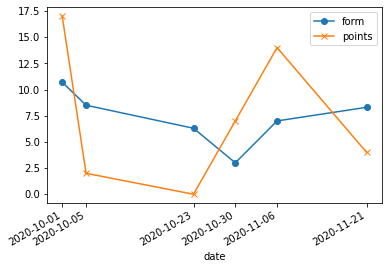

In [399]:
players_analysis[players_analysis['web_name'] == 'Vardy']['form'].plot(label='form', marker='o')
players_analysis[players_analysis['web_name'] == 'Vardy']['event_points'].plot(label = 'points', marker='x')
plt.xticks(x_tick)
plt.legend();

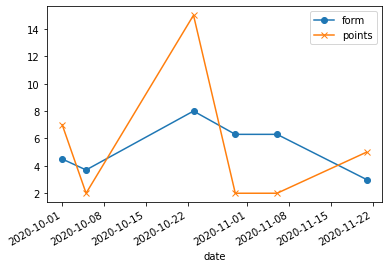

In [485]:
players_analysis[players_analysis['web_name'] == 'Rashford']['form'].plot(label='form', marker='o')
players_analysis[players_analysis['web_name'] == 'Rashford']['event_points'].plot(label = 'points', marker='x')
plt.legend();

In [488]:
players_analysis[players_analysis['web_name'] == 'Rashford']['event_points'].sort_index()

date
2020-10-01     7
2020-10-05     2
2020-10-23    15
2020-10-30     2
2020-11-06     2
2020-11-21     5
Name: event_points, dtype: int64

In [503]:
players_analysis = players_analysis.sort_index()

In [504]:
x = range(6)

In [600]:
y = players_analysis[players_analysis['web_name'] == 'Kane']['event_points'].values

In [601]:
y

array([ 5, 16, 16,  5,  6,  9])

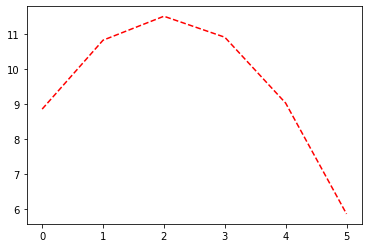

In [605]:
z = np.polyfit(x, y, 2)
p = np.poly1d(z)
plt.plot(x,p(x),"r--")

plt.show()

In [604]:
p

poly1d([-0.6, 11. ])

In [436]:
x_values = players_analysis[players_analysis['web_name'] == 'Werner'].index

In [379]:
players_analysis.columns

Index(['assists', 'bonus', 'bps', 'chance_of_playing_next_round',
       'chance_of_playing_this_round', 'clean_sheets', 'code_x',
       'cost_change_event', 'cost_change_event_fall', 'cost_change_start',
       'cost_change_start_fall', 'creativity', 'dreamteam_count',
       'element_type', 'ep_next', 'ep_this', 'event_points', 'first_name',
       'form', 'goals_conceded', 'goals_scored', 'ict_index', 'i_d',
       'in_dreamteam', 'influence', 'minutes', 'news', 'news_added',
       'now_cost', 'own_goals', 'penalties_missed', 'penalties_saved', 'photo',
       'points_per_game', 'red_cards', 'saves', 'second_name',
       'selected_by_percent', 'special', 'squad_number', 'status', 'team_x',
       'team_code', 'threat', 'total_points', 'transfers_in',
       'transfers_in_event', 'transfers_out', 'transfers_out_event',
       'value_form', 'value_season', 'web_name', 'yellow_cards', 'date_x',
       'minutes_per_game', 'matchday_selection', 'form_index', 'id', 'code_y',
       'na

In [611]:
sorted_players_df_today.name

0            Tottenham Hotspur FC
1                    Liverpool FC
2                 Leeds United FC
3                  Aston Villa FC
4                  Southampton FC
                  ...            
405     Brighton & Hove Albion FC
406                    Arsenal FC
407    Wolverhampton Wanderers FC
408           Sheffield United FC
409                    Chelsea FC
Name: name, Length: 410, dtype: object